In [3]:
import pandas as pd

df = pd.read_csv("../data/spotify/tracks.csv")

df.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

In [6]:
df = df.drop_duplicates()
df = df.dropna()
df.corr(numeric_only=True)['popularity'].sort_values(ascending=False)

popularity          1.000000
loudness            0.327001
energy              0.302178
explicit            0.211749
danceability        0.186878
time_signature      0.086713
tempo               0.071223
duration_ms         0.027638
key                 0.015306
valence             0.004558
mode               -0.033652
speechiness        -0.047415
liveness           -0.048735
instrumentalness   -0.236403
acousticness       -0.370723
Name: popularity, dtype: float64

In [7]:
df['duration_min'] = df['duration_ms'] / 60000

In [11]:
# Engagement Score (weighted logic)
df['engagement_score'] = (
    df['popularity'] * 0.4 +
    df['danceability'] * 20 +
    df['energy'] * 20 +
    (df['duration_min'] * 2)
)

In [12]:
# Normalize score
df['engagement_score'] = (
    (df['engagement_score'] - df['engagement_score'].min()) /
    (df['engagement_score'].max() - df['engagement_score'].min())
)

In [13]:
# Categorize songs
df['engagement_level'] = pd.cut(
    df['engagement_score'],
    bins=[0, 0.3, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)

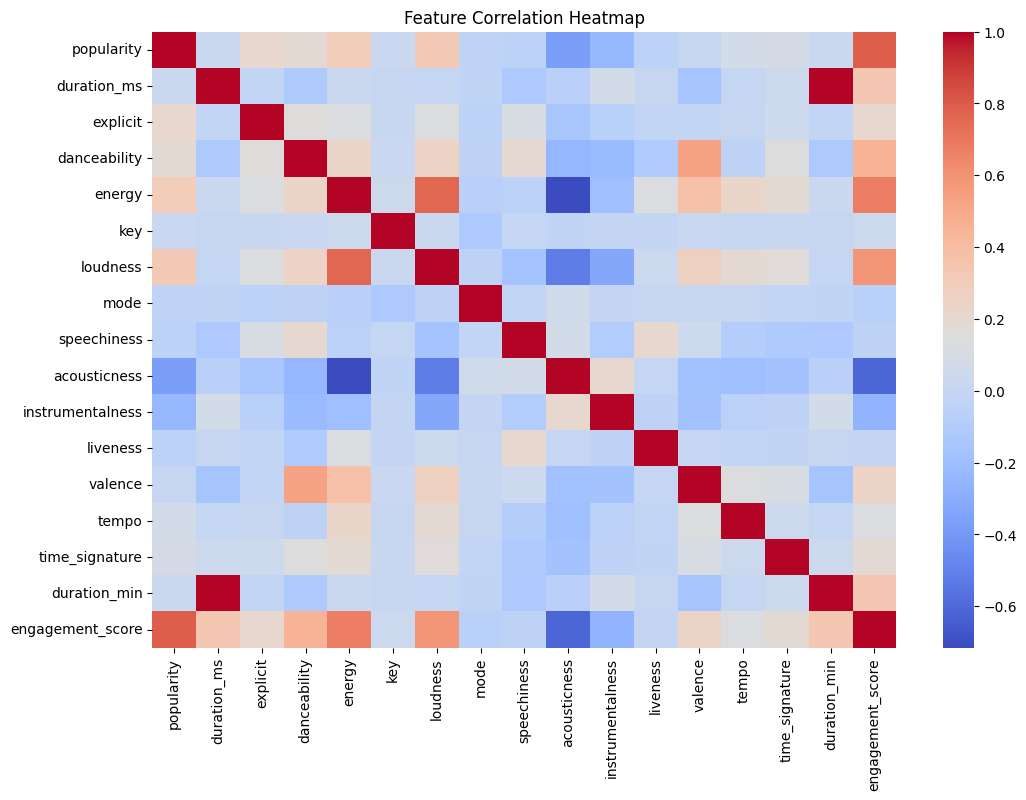

In [14]:
# Correlation heat map
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

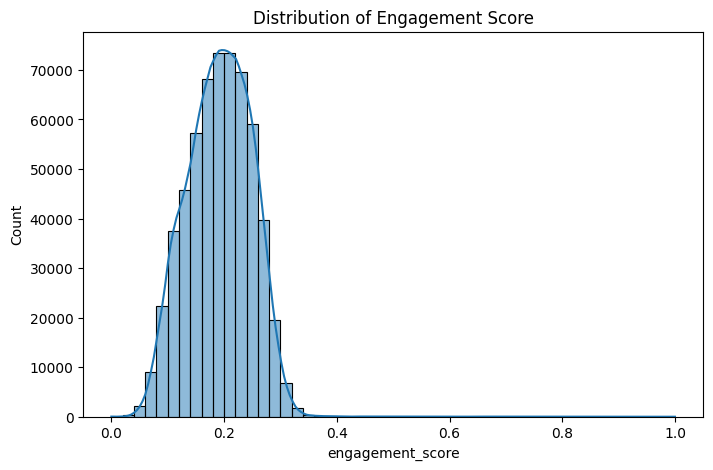

In [15]:
# Engagement Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['engagement_score'], bins=50, kde=True)
plt.title("Distribution of Engagement Score")
plt.show()

c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-

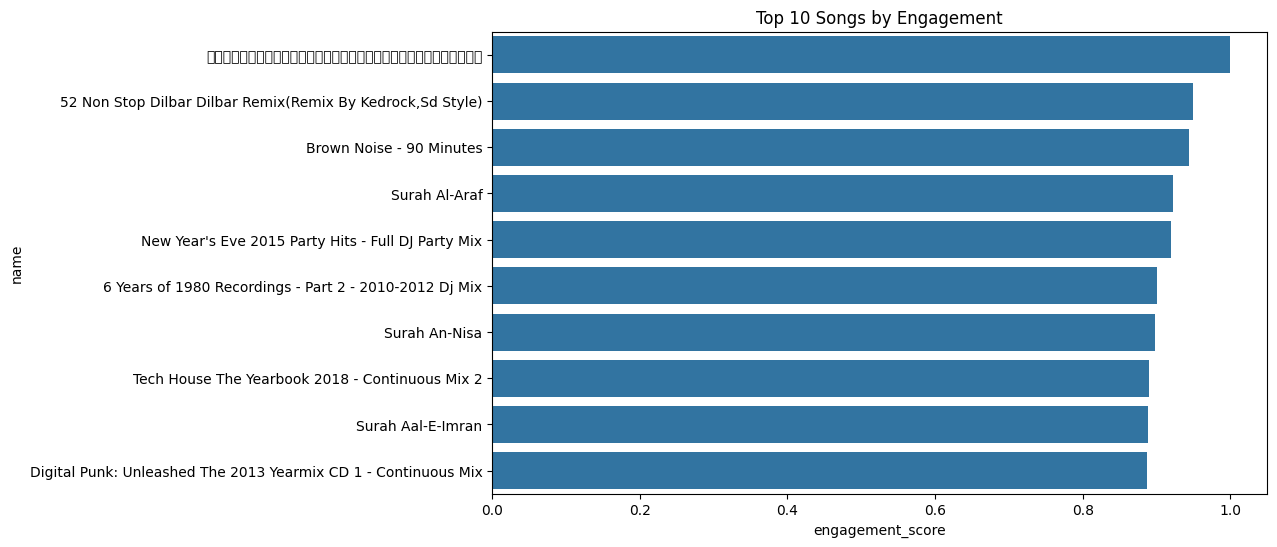

In [ ]:
# Top 10 Performing Songs
top_tracks = df.sort_values(by='engagement_score', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='engagement_score', y='name', data=top_tracks)
plt.title("Top 10 Songs by Engagement")
plt.show()

c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


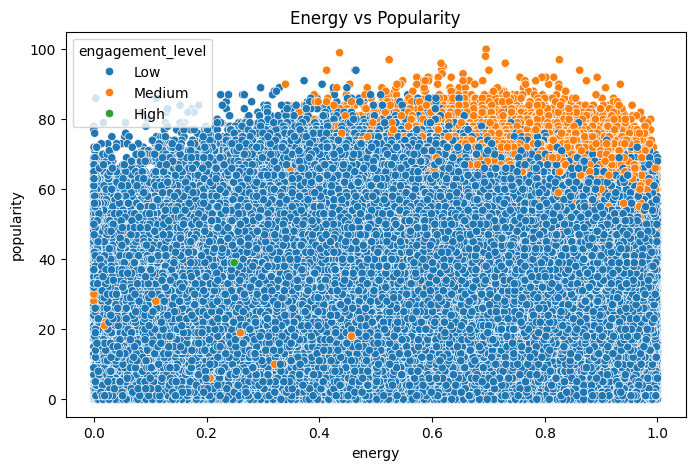

In [17]:
# Energy vs Popularity 
plt.figure(figsize=(8,5))
sns.scatterplot(x='energy', y='popularity', hue='engagement_level', data=df)
plt.title("Energy vs Popularity")
plt.show()

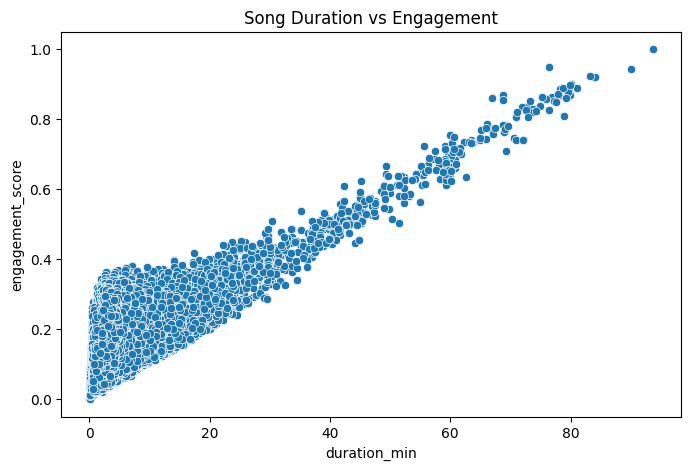

In [18]:
# Duration vs Engagement
plt.figure(figsize=(8,5))
sns.scatterplot(x='duration_min', y='engagement_score', data=df)
plt.title("Song Duration vs Engagement")
plt.show()

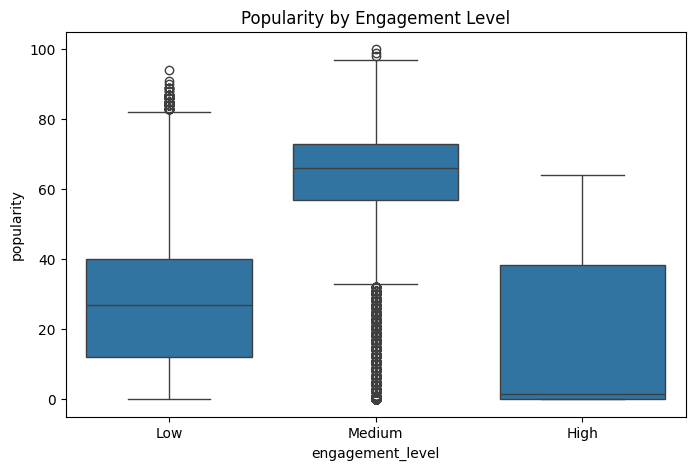

In [19]:
# Engagement by Category
plt.figure(figsize=(8,5))
sns.boxplot(x='engagement_level', y='popularity', data=df)
plt.title("Popularity by Engagement Level")
plt.show()

In [20]:
if df['duration_min'].mean() < 3:
    print("Insight: Shorter songs tend to dominate the platform.")

if df['energy'].corr(df['popularity']) > 0:
    print("Insight: High-energy songs are generally more popular.")

Insight: High-energy songs are generally more popular.


In [21]:
# Normalize (0 to 1 scale)
df['engagement_score'] = (
    (df['engagement_score'] - df['engagement_score'].min()) /
    (df['engagement_score'].max() - df['engagement_score'].min())
)

# Categorize
df['engagement_level'] = pd.cut(
    df['engagement_score'],
    bins=[0, 0.3, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)

In [24]:
if df['engagement_score'].mean() < 0.5:
    print("Most songs have moderate engagement hence opportunity for better content optimization.")

if df['duration_min'].corr(df['engagement_score']) < 0:
    print("Shorter songs tend to perform better on average.")

if df['danceability'].corr(df['engagement_score']) > 0:
    print("Danceable tracks show higher engagement hence users prefer rhythmic content.")

Most songs have moderate engagement hence opportunity for better content optimization.
Danceable tracks show higher engagement hence users prefer rhythmic content.


In [26]:
df.to_csv("../data/processed_spotify.csv", index=False)